In [14]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from read_roi import read_roi_zip
from collections import OrderedDict, Counter
import math
import PIL
from PIL import Image
from PIL.TiffTags import TAGS
import tkinter as tk
from tkinter import filedialog
import seaborn as sns

# Read, format and save raw data from ROIs #

In [240]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)
path

WindowsPath('D:/Sofia/2020-08-25_IRM_DCX-P191R-dyn')

In [241]:
tubulin = '[Tubulin] ' r'$(\mu M)$'
tub = 'tub'

DCXconc = '[DCX] ' r'$(n M)$'
DCX = 'DCX'

investigator = 'Sofia'

In [242]:
dateloc = str(path).find("2020")
date = str(path)[dateloc : dateloc+10]

folders = [x for x in path.iterdir() if x.is_dir()]
folders = [i for i in folders if (str(i)[-7:] == 'results') == True]

ch = []
conc_tub = []
conc_DCX = []
DCX_type = []

for i in folders:
    CHloc = str(i).find("CH")
    tubloc = str(i).rfind(tub)
    DCXloc = str(i).rfind(DCX)
    dcxtype = str(i).find("type")
    ch = ch + [str(i)[CHloc+2:CHloc+4]]
    conc_tub = conc_tub + [(str(i)[tubloc+3:tubloc+5])]
    conc_DCX = conc_DCX + [(str(i)[DCXloc+3:DCXloc+6])]
    DCX_type = DCX_type + [(str(i)[dcxtype+4:DCXloc-1])]

date,ch, conc_tub, conc_DCX, DCX_type

('2020-08-25',
 ['11', '14', '21', '24'],
 ['06', '06', '06', '06'],
 ['100', '050', '050', '014'],
 ['P191R', 'P191R', 'P191R', 'P191R'])

In [243]:
tub_conc =  [float(i) for i in conc_tub]
DCX_conc =  [float(i) for i in conc_DCX]
frame_analyzer = pd.read_csv(path/'frame_rates_avg.csv',sep=',')
pixel =  0.107 #0.107 #0.0633
folders

[WindowsPath('D:/Sofia/2020-08-25_IRM_DCX-P191R-dyn/CH11_tub06uM_typeP191R_DCX100nM-results'),
 WindowsPath('D:/Sofia/2020-08-25_IRM_DCX-P191R-dyn/CH14_tub06uM_typeP191R_DCX050nM-results'),
 WindowsPath('D:/Sofia/2020-08-25_IRM_DCX-P191R-dyn/CH21_tub06uM_typeP191R_DCX050nM-results'),
 WindowsPath('D:/Sofia/2020-08-25_IRM_DCX-P191R-dyn/CH24_tub06uM_typeP191R_DCX014nM-results')]

In [244]:
#frame_analyzer = frame_analyzer.iloc[[1,3]].reset_index()
frame_analyzer

,Directory,Mean,SD,Frames,Outliers,MeanWOutliers,SDWOutliers
0,D:\Sofia\2020-08-25_IRM_DCX-P191R-dyn\CH11_tub...,5.05,0.03,400,1,10.93,117.44
1,D:\Sofia\2020-08-25_IRM_DCX-P191R-dyn\CH12_tub...,5.05,0.03,400,1,10.89,116.65
2,D:\Sofia\2020-08-25_IRM_DCX-P191R-dyn\CH14_tub...,5.04,0.03,400,1,11.22,123.48
3,D:\Sofia\2020-08-25_IRM_DCX-P191R-dyn\CH21_tub...,5.05,0.03,400,1,10.86,116.02
4,D:\Sofia\2020-08-25_IRM_DCX-P191R-dyn\CH24_tub...,5.06,0.03,400,1,10.43,107.33


In [245]:
def open_roi_poly(k,name):
    roi_path = folders[k]/(name)

    roi_data = read_roi_zip(roi_path)
    roi_df = pd.DataFrame(columns=['Track ID','x1','x2','x3','y1','y2','y3'])
    for key in roi_data:
        roi_df = roi_df.append({'Track ID': roi_data[key]['name'],'x1': roi_data[key]['x'][0],'x2': roi_data[key]['x'][1],'x3': roi_data[key]['x'][2],'y1': roi_data[key]['y'][0],'y2': roi_data[key]['y'][1],'y3': roi_data[key]['y'][2]}, ignore_index=True)
    return roi_df

def open_roi_line(k,name):
    roi_path = folders[k]/(name)

    roi_data = read_roi_zip(roi_path)
    roi_df = pd.DataFrame(columns=['Track ID','x1','x2','y1','y2'])
    for key in roi_data:
        roi_df = roi_df.append({'Track ID': roi_data[key]['name'],'x1': roi_data[key]['x1'],'x2': roi_data[key]['x2'],'y1': roi_data[key]['y1'],'y2': roi_data[key]['y2']}, ignore_index=True)
    return roi_df

In [246]:
Length = 'Length ' r'$(\mu m)$'
Lifetime = 'Lifetime ' r'$(min)$'
GrowthRate = 'Growth Rate ' r'$(\mu m / min)$'
TimeToNucleate = 'Time to Nucleate ' r'$(min)$'
ShrinkageLength = 'Shrink Length ' r'$(\mu m)$'
ShrinkageLifetime = 'Shrink Lifetime ' r'$(min)$'
ShrinkageRate = 'Shrink Rate ' r'$(\mu m / min)$'
poly_parameter_names = (Length,Lifetime,GrowthRate,TimeToNucleate)
line_parameter_names = (Length,Lifetime,GrowthRate,TimeToNucleate,ShrinkageLength,ShrinkageLifetime,ShrinkageRate)

In [247]:
def poly_dynamics(k):
        
    data = open_roi_poly(k,'kymoslopes.zip')
    supp = open_roi_line(k,'start.zip')
    
    spf = frame_analyzer['Mean'][k];
    frames = frame_analyzer['Frames'][k]-2
    
    suppn = len(supp)
    start = sum(abs(supp['y2']-supp['y1']))/suppn;
    
    n = len(data)
    pre_df = {'Date': np.full((n), date), 'Investigator': np.full((n), investigator),'CH': np.full((n), ch[k]),tubulin: np.full((n), tub_conc[k]),DCXconc: np.full((n), DCX_conc[k])}
    df = pd.DataFrame(pre_df) 
    
    df[Length] = abs((data['x2']-data['x1'])*pixel)
    
    data[Lifetime] = abs((data['y2']-data['y1'])*spf/60)
    df[Lifetime] = data[[Lifetime,'y2']].apply(lambda x: x[Lifetime] if x['y2'] < frames-2 else np.NaN, axis=1)
    df[Lifetime] = data[[Lifetime,'y2']].apply(lambda x: x[Lifetime] if x[Lifetime] != 0 else np.NaN, axis=1)
    
    df[GrowthRate] = df[Length]/df[Lifetime]
    df[GrowthRate] = df[GrowthRate].apply(lambda x: x if x <= 5 else np.NAN )
    
    df[TimeToNucleate] = (data['y1']-start)*spf/60
    
    df[ShrinkageLength] = abs((data['x3']-data['x2'])*pixel)
    df[ShrinkageLifetime] = abs((data['y3']-data['y2'])*spf/60)
    df[ShrinkageLifetime] = df[ShrinkageLifetime].apply(lambda x: np.NAN if x == 0 else x)
    df[ShrinkageRate] = df[ShrinkageLength]/df[ShrinkageLifetime]
    
    df.loc[pd.isnull(df[GrowthRate]), [Length,Lifetime,TimeToNucleate,ShrinkageLength,ShrinkageLifetime,ShrinkageRate]] = np.NaN
    
    df['Rescues'] = df[[Length,ShrinkageLength]].apply(lambda x: True if abs(x[Length]-x[ShrinkageLength]) > pixel*5 else False, axis=1)
    
    df['DCX Type'] = DCX_type[k]
        
    return df

def line_dynamics(k):
        
    data = open_roi_line(k,'kymoslopes.zip')
    #data_even = data.iloc[::2].reset_index()
    #data_odd = data.iloc[1::2].reset_index()
    data_even = data
    data_odd = data
    
    supp = open_roi_line(k,'start.zip')
    
    spf = frame_analyzer['Mean'][k];
    frames = frame_analyzer['Frames'][k]-2
    
    suppn = len(supp)
    start = sum(abs(supp['y2']-supp['y1']))/suppn;
    
    n = len(data_even)
    pre_df = {'Date': np.full((n), date),'CH': np.full((n), ch[k]),'Concentration ' r'$(\mu M)$': np.full((n), conc[k])}
    df = pd.DataFrame(pre_df) 
    
    data_even[Length] = abs((data_even['x2']-data_even['x1'])*pixel)
    data_even[Lifetime] = abs((data_even['y2']-data_even['y1'])*spf/60)
    df[GrowthRate] = data_even[Length]/data_even[Lifetime]
    df[GrowthRate] = df[GrowthRate].apply(lambda x: x if x <= 5 else np.NaN )
    
    data[Lifetime] = abs((data_odd['y2']-data_odd['y1'])*spf/60)
    df[Lifetime] = data[[Lifetime,'y2']].apply(lambda x: x[Lifetime] if x['y2'] < frames else np.NaN, axis=1)
    
    df[Length] = df[GrowthRate]*df[Lifetime]
    
    df[TimeToNucleate] = ((data_odd[['y1','y2']].min(axis=1))-start)*spf/60
    
    df.loc[pd.isnull(df[GrowthRate]), [Length,Lifetime,TimeToNucleate]] = np.NaN
    
    df = df[['Date','CH','Concentration ' r'$(\mu M)$',Length,Lifetime,GrowthRate,TimeToNucleate]]
        
    return df

In [248]:
path.parents[0]

WindowsPath('D:/Sofia')

In [249]:
newdirectory = str(path.parents[0])+'//Data_Sheets_summer'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)

In [250]:
df = poly_dynamics(0)
for i in range(1,len(ch)):
    df0 = poly_dynamics(i)
    df = df.append(df0, ignore_index=True)

df.to_csv(path/(investigator+'_'+date +'.csv'), encoding='utf-8', index=False)
df.to_csv(newmydir/(investigator+'_'+date+'.csv'), encoding='utf-8', index=False)
df

,Date,Investigator,CH,[Tubulin] $(\mu M)$,[DCX] $(n M)$,Length $(\mu m)$,Lifetime $(min)$,Growth Rate $(\mu m / min)$,Time to Nucleate $(min)$,Shrink Length $(\mu m)$,Shrink Lifetime $(min)$,Shrink Rate $(\mu m / min)$,Rescues,DCX Type
0,2020-08-25,Sofia,11,6.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,P191R
1,2020-08-25,Sofia,11,6.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,P191R
2,2020-08-25,Sofia,11,6.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,P191R
3,2020-08-25,Sofia,11,6.0,100.0,1.605000,2.903750,0.552734,0.883750,0.998667,1.304583,0.765506,True,P191R
4,2020-08-25,Sofia,11,6.0,100.0,1.792250,4.629167,0.387165,17.548750,2.434250,0.462917,5.258506,True,P191R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,2020-08-25,Sofia,24,6.0,14.0,0.575125,1.472917,0.390467,17.811771,0.494875,0.294583,1.679915,False,P191R
249,2020-08-25,Sofia,24,6.0,14.0,1.952750,4.797500,0.407035,13.561354,2.273750,0.315625,7.203960,False,P191R
250,2020-08-25,Sofia,24,6.0,14.0,0.873833,2.665278,0.327858,1.700868,1.016500,0.448888,2.264483,False,P191R
251,2020-08-25,Sofia,24,6.0,14.0,0.535000,0.911805,0.586748,2.809063,0.570667,0.182361,3.129322,False,P191R


In [251]:
dfmean = df.groupby('CH').mean()
#dfmean.to_csv(path/(date+'_0_mean.csv'), encoding='utf-8', index=False)
dfmean

,[Tubulin] $(\mu M)$,[DCX] $(n M)$,Length $(\mu m)$,Lifetime $(min)$,Growth Rate $(\mu m / min)$,Time to Nucleate $(min)$,Shrink Length $(\mu m)$,Shrink Lifetime $(min)$,Shrink Rate $(\mu m / min)$,Rescues
CH,,,,,,,,,,
11,6.0,100.0,2.470030,5.828728,0.441042,6.196371,2.132834,1.065401,2.355934,0.220000
14,6.0,50.0,2.553986,5.716913,0.451409,3.094508,2.456370,0.566092,5.507246,0.077922
21,6.0,50.0,1.290106,3.638240,0.387379,9.119498,1.295248,0.481223,4.444343,0.018182
24,6.0,14.0,1.130002,3.161748,0.381628,7.116310,1.187689,0.228768,7.968531,0.000000


In [239]:
dfstd = df.groupby('CH').std()
#dfstd.to_csv(path/(date+'_0_std.csv'), encoding='utf-8', index=False)
dfstd

,[Tubulin] $(\mu M)$,[DCX] $(n M)$,Length $(\mu m)$,Lifetime $(min)$,Growth Rate $(\mu m / min)$,Time to Nucleate $(min)$,Shrink Length $(\mu m)$,Shrink Lifetime $(min)$,Shrink Rate $(\mu m / min)$,Rescues
CH,,,,,,,,,,
12,0.0,0.0,2.094409,5.499029,0.061690,0.915700,2.015351,1.942730,0.843114,0.379057
22,0.0,0.0,1.116181,2.559222,0.057370,3.957715,0.878016,0.691709,1.416580,0.491507
24,0.0,0.0,1.983351,5.915955,0.050864,7.366701,0.994921,1.031407,0.476663,0.496593


# Preliminary plot Histograms #

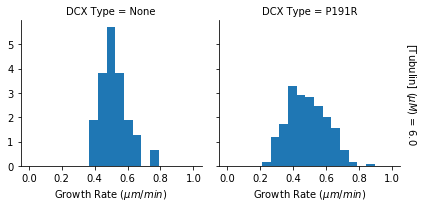

In [130]:
g = sns.FacetGrid(df, row=tubulin, col='DCX Type', margin_titles=True)
bins = np.linspace(0, 1, 20)
g.map(plt.hist, GrowthRate, bins=bins, density=True)

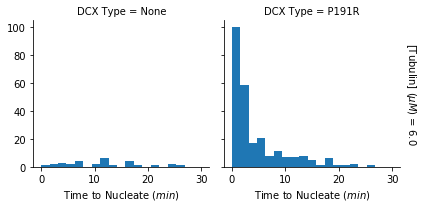

In [131]:
g = sns.FacetGrid(df, row=tubulin, col="DCX Type", margin_titles=True)
bins = np.linspace(0, 30, 20)
g.map(plt.hist, TimeToNucleate, bins=bins)

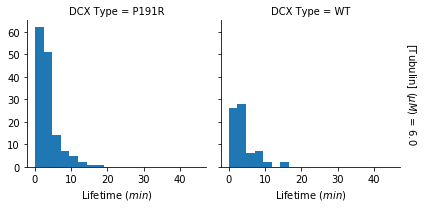

In [18]:
g = sns.FacetGrid(df, row=tubulin, col="DCX Type", margin_titles=True)
bins = np.linspace(0, 45, 20)
g.map(plt.hist, Lifetime, bins=bins)

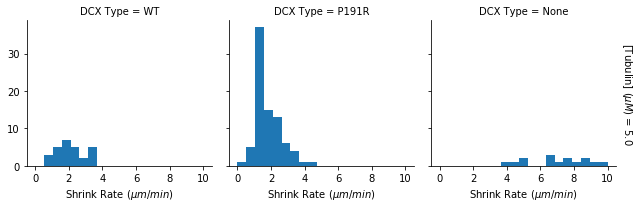

In [53]:
g = sns.FacetGrid(df, row=tubulin, col="DCX Type", margin_titles=True)
bins = np.linspace(0, 10, 20)
g.map(plt.hist, ShrinkageRate, bins=bins)